In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.utils.data
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

/Users/itzjuztmya/miniconda3/envs/school/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# this is a transform to normalize these images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1307,], std=[0.3081,])
])

# Download and load the train and test data
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
print(f"MNIST training data loaded: {len(train_dataset)} samples")
print(f"MNIST test data loaded: {len(test_dataset)} samples")

# Filter the data to make this a binary problem. We will look at multi-class next but let's start with binary.
def filter_labels_0_1(dataset):
    # Initialize an empty list to store the indices
    indices_0_1 = []

    # Iterate through the data
    for i, (image, label) in enumerate(dataset):
        # Check if the label is 0 or 1
        if label == 0 or label == 1:
            indices_0_1.append(i)

    # Create a new Subset using the original dataset and the collected indices
    filtered_dataset = torch.utils.data.Subset(dataset, indices_0_1)

    return filtered_dataset

train_dataset_binary = filter_labels_0_1(train_dataset)
test_dataset_binary = filter_labels_0_1(test_dataset)

print(f"Filtered MNIST training data loaded: {len(train_dataset_binary)} samples")
print(f"Filtered MNIST test data loaded: {len(test_dataset_binary)} samples")

MNIST training data loaded: 60000 samples
MNIST test data loaded: 10000 samples
Filtered MNIST training data loaded: 12665 samples
Filtered MNIST test data loaded: 2115 samples


In [3]:
# Subset the filtered training data to 50% of its size
# Calculate the number of samples for 50%
total_size = len(train_dataset_binary)
subset_size = total_size // 2

# Generate random indices for the subset
all_indices = list(range(total_size))
random.shuffle(all_indices)
subset_indices = all_indices[:subset_size]

# Create the subset
train_dataset_binary_subset = torch.utils.data.Subset(train_dataset_binary, subset_indices)

print(f"Original filtered training size: {total_size}")
print(f"New 50% subset training size: {len(train_dataset_binary_subset)}")

# Re-assign to train_dataset_binary if you want to use it in the existing training loop
# train_dataset_binary = train_dataset_binary_subset

Original filtered training size: 12665
New 50% subset training size: 6332


Index: 7889


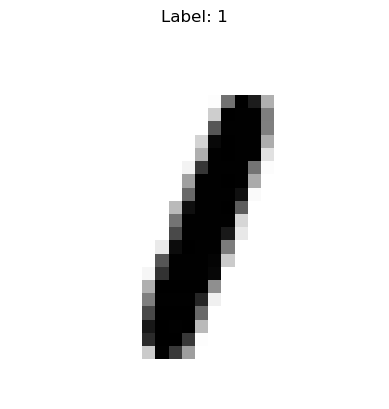

In [4]:
# visualize our input data
def plot_random_train_image(dataset=train_dataset_binary):

    # get random index
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]
    print(f"Index: {idx}")

    # Unnormalize for visualization
    # The original transform was Normalize(mean=[0.1307], std=[0.3081])
    # Formula: unnormalized = (normalized * std) + mean
    mean = 0.1307
    std = 0.3081
    unnormalized_image = image * std + mean

    plt.imshow(unnormalized_image.squeeze(), cmap='gray_r')
    plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

# Plot a random sample from the filtered training data
plot_random_train_image()

In [5]:
# create a CNN class
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Layer 1: 1 input channel (grayscale), 32 output channels, 3x3 filter
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding='valid')

        # Layer 2: 32 input channels, 64 output channels, 5x5 filter
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding='valid')

        # Fully connected layers
        self.fc1 = nn.Linear(22 * 22 * 32, 64) # 28 x 28 image becomes 22 x 22 after the conv layers
        self.fc2 = nn.Linear(64, 1)

        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.1)

        # activation function
        self.ReLU = nn.ReLU()

        # sigmoid for binary classification
        self.sigmoid = nn.Sigmoid()


    def forward(self, x):
        # First Conv block
        x = self.ReLU(self.conv1(x))

        # Second Conv block
        x = self.ReLU(self.conv2(x))

        # Flatten the 3D tensor into a 1D vector for the FC layers
        x = torch.flatten(x, 1)

        # Fully connected layers with Dropout
        x = self.ReLU(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        #sigmoid function to make prediction binary
        return self.sigmoid(x)

# Instantiate the model
model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=valid)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=valid)
  (fc1): Linear(in_features=15488, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (ReLU): ReLU()
  (sigmoid): Sigmoid()
)


In [6]:
seed = 499
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [7]:
# Create data loaders for CNN using the binary filtered datasets
batch_size = 256
train_loader = torch.utils.data.DataLoader(train_dataset_binary, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset_binary, batch_size=batch_size, shuffle=False)

# Initialize the model
model = SimpleCNN()

# Define Loss function and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Lists for tracking metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Training loop
epochs = 20

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    train_total_correct = 0

    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data).view(-1)  # Flatten output to match target shape [batch_size]

        # target needs to be float for BCELoss
        target = target.float()

        # calculate loss and backprop
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # calculate accuracy
        preds = (output > 0.5).float()
        train_total_correct += (preds == target).sum().item()

    train_losses.append(train_loss / len(train_dataset_binary))
    train_accuracies.append(train_total_correct / len(train_dataset_binary))

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    val_total_correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data).view(-1)
            target = target.float()

            loss = criterion(output, target)
            val_loss += loss.item()

            preds = (output > 0.5).float()
            val_total_correct += (preds == target).sum().item()

    val_losses.append(val_loss / len(test_dataset_binary))
    val_accuracies.append(val_total_correct / len(test_dataset_binary))

    print(f"Epoch {epoch+1}/{epochs}: Train Acc: {train_accuracies[-1]:.4f} | Val Acc: {val_accuracies[-1]:.4f} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

Epoch 1/20: Train Acc: 0.9610 | Val Acc: 0.9967 | Train Loss: 0.0020 | Val Loss: 0.0014
Epoch 2/20: Train Acc: 0.9950 | Val Acc: 0.9967 | Train Loss: 0.0009 | Val Loss: 0.0006
Epoch 3/20: Train Acc: 0.9955 | Val Acc: 0.9976 | Train Loss: 0.0004 | Val Loss: 0.0003
Epoch 4/20: Train Acc: 0.9955 | Val Acc: 0.9981 | Train Loss: 0.0002 | Val Loss: 0.0002
Epoch 5/20: Train Acc: 0.9967 | Val Acc: 0.9991 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 6/20: Train Acc: 0.9965 | Val Acc: 0.9991 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 7/20: Train Acc: 0.9969 | Val Acc: 0.9991 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 8/20: Train Acc: 0.9970 | Val Acc: 0.9991 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 9/20: Train Acc: 0.9973 | Val Acc: 0.9991 | Train Loss: 0.0001 | Val Loss: 0.0000
Epoch 10/20: Train Acc: 0.9976 | Val Acc: 0.9991 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 11/20: Train Acc: 0.9978 | Val Acc: 0.9991 | Train Loss: 0.0000 | Val Loss: 0.0000
Epoch 12/20: Train Acc: 0.9977

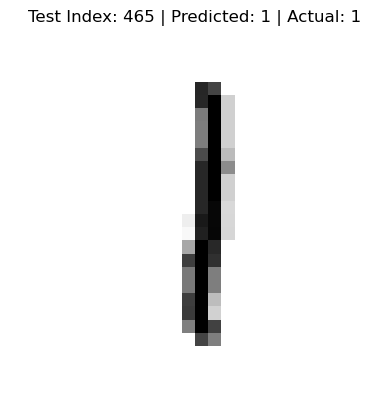

In [8]:
def predict_and_plot(dataset=test_dataset_binary, model=model):
    # Choose a random row from test data
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]

    # Use the model to predict the label
    model.eval()
    with torch.no_grad():
        # Add batch dimension [1, 1, 28, 28]
        input_tensor = image.unsqueeze(0)
        output = model(input_tensor)
        prediction = 1 if output.item() > 0.5 else 0

    # Plot the input and display prediction
    # Unnormalize for visualization
    mean, std = 0.1307, 0.3081
    unnormalized_image = image * std + mean

    plt.imshow(unnormalized_image.squeeze(), cmap='gray_r')
    plt.title(f"Test Index: {idx} | Predicted: {prediction} | Actual: {label}")
    plt.axis('off')
    plt.show()


# Run the function
predict_and_plot()